# Taller 2 · Punto 11: Modelos de tormenta convergente

**Modelación de Sistemas y Procesos Hidrológicos · ICYA 4710**

**Desarrollado por: Daniel Ojeda y Carlos Dominguez**

## Objetivo

Explicar cómo estimar la intensidad de la lluvia y la eficiencia en cuatro modelos de tormenta convergente: entrada radial, salida de compensación, celda convectiva igualmente proporcionada y celda convectiva de diferentes proporciones.

Para cada modelo se presentarán su representación conceptual, las ecuaciones utilizadas, las variables y sus unidades, los supuestos y un ejemplo numérico desarrollado en Python.

## Verificación del entorno
Se comprueba la versión de Python, la ubicación del intérprete y la
disponibilidad de las librerías utilizadas para los cálculos, las tablas
y las gráficas.


In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Versión de Python:", sys.version.split()[0])
print("Ejecutable:", sys.executable)
print("Versión de NumPy:", np.__version__)

Versión de Python: 3.12.13
Ejecutable: /Users/santiagoojeda/miniconda3/envs/hidro/bin/python
Versión de NumPy: 2.5.2


## 1. Conceptos comunes y unidades

### Intensidad de lluvia

La intensidad de lluvia representa la lámina de agua que llega a una superficie por unidad de tiempo (mm/h).

Si conocemos la tasa de masa de agua que llega al suelo y el área sobre la cual se distribuye, la intensidad media sobre esa área es:

$$
i = \frac{\dot{m}_P}{\rho_w A}
$$

donde:

- $\dot{m}_P$: tasa de masa de agua que llega al suelo como precipitación, en kg/s.
- $\rho_w$: densidad del agua líquida, que se aproxima como 1000 kg/m³.
- $A$: área sobre la cual se calcula la intensidad media, en m².
- $i$: intensidad de lluvia, obtenida inicialmente en m/s.

Para expresar el resultado en mm/h:

$$
i_{\mathrm{mm/h}} =
\frac{\dot{m}_P}{\rho_w A}
\times 1000 \times 3600
$$


### Eficiencia de precipitación

La eficiencia relaciona la precipitación producida con una cantidad de agua de referencia.

En cada modelo se indicará explícitamente el numerador, el denominador y los supuestos empleados para calcular la eficiencia.

[Sui, Li y Yang (2007), *On the Definition of Precipitation Efficiency*](https://doi.org/10.1175/2007JAS2332.1).

In [2]:
# Ejemplo: conversión de flujo de agua a intensidad de lluvia
rho_agua = 1000.0         # kg/m³
area_m2 = 1_000_000.0     # m²: equivale a 1 km²
flujo_lluvia_kg_s = 1000.0  # kg/s de agua que llega al suelo

intensidad_m_s = flujo_lluvia_kg_s / (rho_agua * area_m2)
intensidad_mm_h = intensidad_m_s * 1000 * 3600

print(f"Intensidad de lluvia: {intensidad_mm_h:.2f} mm/h")

Intensidad de lluvia: 3.60 mm/h


### Balance de agua del sistema

Consideramos un volumen de control que contiene la nube y la columna de aire hasta el suelo. El agua puede entrar como vapor, salir como vapor o llegar al suelo como precipitación. También puede acumularse dentro del sistema.

Para este balance suponemos que:

- El agua transportada por el aire a través de los límites entra y sale únicamente como vapor; no hay transporte de gotas o hielo a través de los límites laterales o superiores.
- Se desprecia el aporte de agua por evaporación desde la superficie.
- La precipitación se evalúa cuando llega al suelo.
- El almacenamiento incluye el agua presente como vapor, líquido y hielo.

Bajo estas condiciones, la conservación de la masa de agua se expresa como:

$$
\frac{dM}{dt}
=
F_{\mathrm{entrada}}
-
F_{\mathrm{salida}}
-
\dot{m}_P
$$

Aquí, $M$ es la masa de agua almacenada en el sistema, en kg. Los flujos de entrada, salida y precipitación se expresan en kg/s.

La condensación transforma vapor en agua líquida, pero no elimina agua del volumen de control; por eso no aparece como una salida en este balance de agua total.

### Aproximación de estado estacionario

Si la masa de agua almacenada permanece constante:

$$
\frac{dM}{dt}=0
$$

Entonces:

$$
\dot{m}_P
=
F_{\mathrm{entrada}}
-
F_{\mathrm{salida}}
$$

Para este caso simplificado, definimos una eficiencia respecto al flujo de vapor entrante:

$$
\eta_{\mathrm{entrada}}
=
\frac{\dot{m}_P}{F_{\mathrm{entrada}}}
$$


In [3]:
# Flujos de vapor de agua: valores supuestos para este ejemplo
flujo_entrada_kg_s = 2000.0
flujo_salida_kg_s = 500.0

# Precipitación obtenida mediante el balance estacionario
flujo_lluvia_kg_s = flujo_entrada_kg_s - flujo_salida_kg_s

# Eficiencia respecto al vapor que entra
eficiencia = flujo_lluvia_kg_s / flujo_entrada_kg_s
eficiencia_porcentaje = eficiencia * 100

# Conversión de la precipitación a intensidad media sobre 1 km²
rho_agua = 1000.0
area_m2 = 1_000_000.0

intensidad_mm_h = (
    flujo_lluvia_kg_s / (rho_agua * area_m2) * 1000 * 3600
)

print(f"Agua que llega al suelo: {flujo_lluvia_kg_s:.1f} kg/s")
print(f"Eficiencia respecto a la entrada: {eficiencia_porcentaje:.1f} %")
print(f"Intensidad media de lluvia: {intensidad_mm_h:.2f} mm/h")

Agua que llega al suelo: 1500.0 kg/s
Eficiencia respecto a la entrada: 75.0 %
Intensidad media de lluvia: 5.40 mm/h


Ingresan 2000 kg/s de vapor y salen 500 kg/s. suponiendo que el almacenamiento es contante, se precipitan 1500 kg/s, el cual representa una eficiencia del 75% y una intensidad media de lluvia de 5.40 mm/h sobre 1 km².

## 2. Modelo de entrada radial 

El aire húmedo entra por los lados de una región cilíndrica y asciende. Para este caso ideal suponemos condiciones constantes, vapor uniforme en la capa de entrada y que toda el agua entrante llega al suelo como lluvia. El aire seco puede salir por arriba; se desprecia el vapor que lo acompaña.

El área lateral de entrada y el área donde cae la lluvia son:

$$
A_e = 2\pi Rh,\qquad A_p = \pi R^2
$$

La entrada de vapor es:

$$
F_e = \rho_v u A_e
$$

Aquí, $R$ es el radio (m), $h$ el espesor de la capa de entrada (m), $u$ la velocidad radial entrante (m/s) y $\rho_v$ la densidad de vapor (kg/m³).

Como se desprecia la salida de vapor y no cambia el almacenamiento:

$$
i=\frac{F_e}{\rho_w A_p}\,1000\,3600,
\qquad
\eta=\frac{F_e}{F_e}=1
$$

La intensidad queda en mm/h. La eficiencia del 100 % es consecuencia del supuesto ideal, no una propiedad de todas las tormentas con entrada radial.

**Ejemplo**

In [4]:
# Datos del ejemplo
radio = 5000.0           # m
altura_entrada = 1000.0  # m
velocidad = 2.0         # m/s
rho_vapor = 0.015       # kg de vapor/m³ de aire
rho_agua = 1000.0       # kg/m³

# Geometría y entrada de vapor
area_entrada = 2 * np.pi * radio * altura_entrada
area_lluvia = np.pi * radio**2
entrada = rho_vapor * velocidad * area_entrada

# Balance del caso ideal
salida = 0.0
lluvia = entrada - salida

intensidad_radial = lluvia / (rho_agua * area_lluvia) * 1000 * 3600
eficiencia_radial = 100 * lluvia / entrada

print(f"Intensidad: {intensidad_radial:.2f} mm/h")
print(f"Eficiencia: {eficiencia_radial:.1f} %")

Intensidad: 43.20 mm/h
Eficiencia: 100.0 %


El ejemplo produce 43.20 mm/h y la eficiencia es del 100% debido a que todo el vapor entrante se precipita por lo que representa un límite ideal

## 3. Modelo con salida de compensación

En este caso, el aire entra por la parte baja y sale por arriba llevando algo de vapor. Por eso, no toda el agua que entra se convierte en lluvia.

Se mantiene la geometría y los datos del ejemplo anterior. Suponemos una densidad de aire seco de 1,15 kg/m³ y una relación de mezcla de salida de 3 g de vapor por kg de aire seco. Trabajamos en estado estacionario, sin evaporación superficial ni salida de gotas por arriba.

El flujo de aire seco se conserva entre la entrada y la salida:

$$
\dot{m}_d = \rho_d u A_e
$$

El vapor que sale se calcula como:

$$
F_s = \dot{m}_d r_s
$$

donde $r_s = 0,003$ kg de vapor/kg de aire seco. La lluvia y la eficiencia respecto al vapor entrante son:

$$
\dot{m}_P = F_e-F_s,\qquad
\eta = \frac{F_e-F_s}{F_e}
$$

La intensidad se obtiene dividiendo la lluvia entre la densidad del agua y el área de precipitación, como en el ejemplo anterior.

**Ejemplo**

In [5]:
# Datos supuestos para la salida
rho_aire_seco = 1.15       # kg/m³
relacion_mezcla_salida = 3 / 1000  # de g/kg a kg/kg

# El mismo flujo de aire seco entra y sale
flujo_aire_seco = rho_aire_seco * velocidad * area_entrada

# Vapor que sale y agua que precipita
salida_compensacion = flujo_aire_seco * relacion_mezcla_salida
lluvia_compensacion = entrada - salida_compensacion

# Intensidad en mm/h y eficiencia en porcentaje
intensidad_compensacion = (
    lluvia_compensacion / (rho_agua * area_lluvia) * 1000 * 3600
)
eficiencia_compensacion = 100 * lluvia_compensacion / entrada

print(f"Intensidad: {intensidad_compensacion:.2f} mm/h")
print(f"Eficiencia: {eficiencia_compensacion:.1f} %")

Intensidad: 33.26 mm/h
Eficiencia: 77.0 %


En el ejemplo, la intensidad baja de 43.20 a 33.26 mm/h debido a que parte del vapor sale con el aire. Se determina que el 77% del agua entrante se precipita y el 23% restante sale como vapor.

## 4. Celda convectiva igualmente proporcionada

Representamos la celda con entrada de aire húmedo abajo y salida arriba. Para este ejemplo suponemos áreas de entrada y salida iguales, flujo estacionario y ausencia de pérdidas de gotas.

Conservamos el flujo de aire seco:

$$
\rho_{d,e}\,u_e\,A_e=\rho_{d,s}\,u_s\,A_s
$$

La velocidad de salida se calcula con esta igualdad. La lluvia corresponde a la diferencia entre el vapor que entra y el que sale.

**Ejemplo**

In [6]:
area_salida_celda = area_entrada
rho_seco_salida = 0.50  # kg/m³, valor supuesto

velocidad_salida_celda = (
    flujo_aire_seco / (rho_seco_salida * area_salida_celda)
)

vapor_salida_celda = (
    rho_seco_salida
    * velocidad_salida_celda
    * area_salida_celda
    * relacion_mezcla_salida
)

lluvia_celda = entrada - vapor_salida_celda

intensidad_celda = (
    lluvia_celda / (rho_agua * area_lluvia) * 1000 * 3600
)
eficiencia_celda = 100 * lluvia_celda / entrada

print(f"Velocidad de salida: {velocidad_salida_celda:.2f} m/s")
print(f"Intensidad: {intensidad_celda:.2f} mm/h")
print(f"Eficiencia: {eficiencia_celda:.2f} %")

Velocidad de salida: 4.60 m/s
Intensidad: 33.26 mm/h
Eficiencia: 77.00 %


Como el aire de salida tiene menor densidad, debe salir más rápido para conservar la masa de aire seco.

## 5. Celda convectiva de diferentes proporciones

En este caso, suponemos que el área de salida es el doble del área de entrada:

$$A_s = 2A_e$$

Mantenemos el flujo estacionario, las densidades, la humedad y el área sobre la que llueve del ejemplo anterior. La velocidad de salida debe ajustarse para conservar el flujo de aire seco:

$$u_s = \frac{\dot{m}_d}{\rho_{d,s}A_s}$$

Con esta comparación evaluamos qué cambia al ampliar únicamente la sección de salida.

**Ejemplo**

In [7]:
area_salida_diferente = 2 * area_entrada

velocidad_salida_diferente = (
    flujo_aire_seco / (rho_seco_salida * area_salida_diferente)
)

vapor_salida_diferente = (
    rho_seco_salida
    * velocidad_salida_diferente
    * area_salida_diferente
    * relacion_mezcla_salida
)

lluvia_diferente = entrada - vapor_salida_diferente

intensidad_diferente = (
    lluvia_diferente / (rho_agua * area_lluvia) * 1000 * 3600
)
eficiencia_diferente = 100 * lluvia_diferente / entrada

print(f"Velocidad de salida: {velocidad_salida_diferente:.2f} m/s")
print(f"Intensidad: {intensidad_diferente:.2f} mm/h")
print(f"Eficiencia: {eficiencia_diferente:.2f} %")

Velocidad de salida: 2.30 m/s
Intensidad: 33.26 mm/h
Eficiencia: 77.00 %


Al duplicar el área de salida, la velocidad disminuyea la mitad, de 4.60 a 2.30 m/s. La intensidad y la eficiencia permanecen iguales porque se mantienen el flujo de vapor entrante, la humedad de salida y el área de lluvia. Por lo tanto, cambiar solamente el área de salida no modifica la precipitación.

## 6. Comparación e interpretación de resultados

In [8]:
comparacion = pd.DataFrame({
    "Modelo o caso": [
        "Entrada radial ideal",
        "Salida de compensación",
        "Celda con áreas iguales",
        "Celda con salida de doble área"
    ],
    "Intensidad (mm/h)": [
        intensidad_radial,
        intensidad_compensacion,
        intensidad_celda,
        intensidad_diferente
    ],
    "Eficiencia (%)": [
        eficiencia_radial,
        eficiencia_compensacion,
        eficiencia_celda,
        eficiencia_diferente
    ]
})

comparacion.round(2)

,Modelo o caso,Intensidad (mm/h),Eficiencia (%)
0,Entrada radial ideal,43.20,100.0
1,Salida de compensación,33.26,77.0
2,Celda con áreas iguales,33.26,77.0
3,Celda con salida de doble área,33.26,77.0


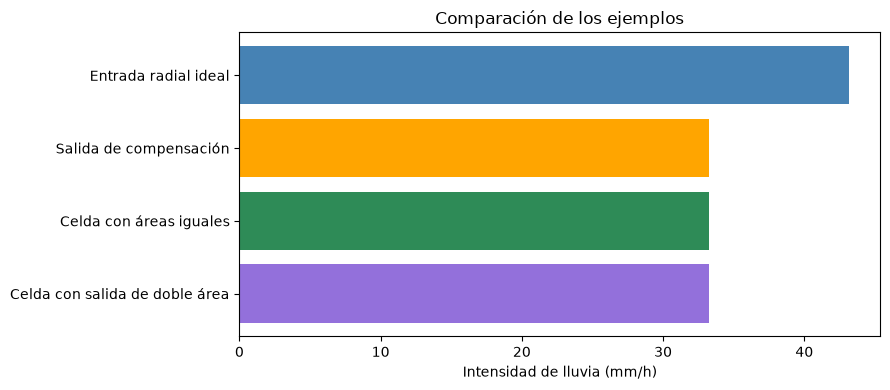

In [9]:
plt.figure(figsize=(9, 4))

plt.barh(
    comparacion["Modelo o caso"],
    comparacion["Intensidad (mm/h)"],
    color=["steelblue", "orange", "seagreen", "mediumpurple"]
)

# Mantener el mismo orden de la tabla
plt.gca().invert_yaxis()

plt.xlabel("Intensidad de lluvia (mm/h)")
plt.title("Comparación de los ejemplos")
plt.tight_layout()
plt.show()

El modelo radial ideal alcanza 43.20 mm/h suponiendo que todo el vapor entrante precipita. Los otros tres ejemplos producen 33.26 mm/h y una eficiencia del 77 %. En los dos casos de celda, cambiar el área de salida modifica la velocidad, pero no la lluvia, porque se mantienen el flujo de aire seco y la humedad de salida.

## 7. Conclusiones

En estos ejemplos vimos que no todo el vapor que entra a una tormenta termina precipitándose, ya que una parte puede salir con el aire. Por eso, al incluir esa salida, la intensidad bajó de 43.20 a 33.26 mm/h y la eficiencia pasó del 100 % al 77 %.

También vimos que aumentar el área de salida no necesariamente produce más o menos lluvia. En este caso, el aire salió más despacio, pero transportó la misma cantidad de vapor, por lo que la precipitación no cambió.

## 8. Referencias

Chow, V. T., Maidment, D. R., & Mays, L. W. (1988). *Applied Hydrology*. McGraw-Hill. Sección 3.3: modelo de celda de tormenta.

### Uso de herramientas de IA

Se utilizó la IA como apoyo para organizar el notebook, entender las ecuaciones y elaborar el código.